<a href="https://colab.research.google.com/github/hayajahan07/ACMRecruitment-hayajahan07/blob/main/questline-2/2a-2e/solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load titanic (from your previous file or download again)
try:
    df = pd.read_csv('titanic.csv')
except:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# 2a — Decode the Passenger Records
from sklearn.preprocessing import LabelEncoder

print("Before Encoding:")
print(df[['Sex','Embarked']].head())
print(df['Sex'].unique(), df['Embarked'].unique())

# 1. Label Encode Sex -> Binary, so Label Encoding is perfect
# Why LabelEncode for Sex? Only 2 categories (male/female).
# No ordinality issue, creates single column 0/1. One-hot would be wasteful (2 columns).

le = LabelEncoder()
df['Sex_encoded'] = le.fit_transform(df['Sex']) # male=1, female=0 (or vice versa)
print(f"\nSex mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# 2. One-Hot Encode Embarked -> 3 categories, nominal (no order)
# Why One-Hot for Embarked? It has 3 ports S,C,Q. If we Label Encode 0,1,2 model thinks S<C<Q (order) which is wrong.
# One-hot creates 3 separate binary columns, no false ordering.

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0]) # fill missing
df_encoded = pd.get_dummies(df, columns=['Embarked'], prefix='Embarked', drop_first=False)
# drop_first=False to keep all 3 for understanding. In model you can use drop_first=True to avoid multicollinearity.

print("\nAfter Encoding:")
print(df_encoded[['Sex','Sex_encoded','Embarked_C','Embarked_Q','Embarked_S']].head())

# Explanation for submission:
print("""
2a Explanation:
- Sex: Label Encoding (male/female -> 0/1). Reason: Binary feature, efficient, no ordinality problem.
- Embarked: One-Hot Encoding (S,C,Q -> 3 columns). Reason: Nominal with 3 values, no natural order. Prevents model assuming numerical relationship.
""")


Before Encoding:
      Sex Embarked
0    male        S
1  female        C
2  female        S
3  female        S
4    male        S
['male' 'female'] ['S' 'C' 'Q' nan]

Sex mapping: {'female': np.int64(0), 'male': np.int64(1)}

After Encoding:
      Sex  Sex_encoded  Embarked_C  Embarked_Q  Embarked_S
0    male            1       False       False        True
1  female            0        True       False       False
2  female            0       False       False        True
3  female            0       False       False        True
4    male            1       False       False        True

2a Explanation:
- Sex: Label Encoding (male/female -> 0/1). Reason: Binary feature, efficient, no ordinality problem.
- Embarked: One-Hot Encoding (S,C,Q -> 3 columns). Reason: Nominal with 3 values, no natural order. Prevents model assuming numerical relationship.



Before Scaling:
              Age        Fare
count  891.000000  891.000000
mean    29.361582   32.204208
std     13.019697   49.693429
min      0.420000    0.000000
25%     22.000000    7.910400
50%     28.000000   14.454200
75%     35.000000   31.000000
max     80.000000  512.329200

After MinMax (0 to 1):
       Age_minmax  Fare_minmax
count  891.000000   891.000000
mean     0.363679     0.062858
std      0.163605     0.096995
min      0.000000     0.000000
25%      0.271174     0.015440
50%      0.346569     0.028213
75%      0.434531     0.060508
max      1.000000     1.000000

After Standard (mean~0, std~1):
       Age_standard  Fare_standard
count  8.910000e+02   8.910000e+02
mean   2.272780e-16   3.987333e-18
std    1.000562e+00   1.000562e+00
min   -2.224156e+00  -6.484217e-01
25%   -5.657365e-01  -4.891482e-01
50%   -1.046374e-01  -3.573909e-01
75%    4.333115e-01  -2.424635e-02
max    3.891554e+00   9.667167e+00


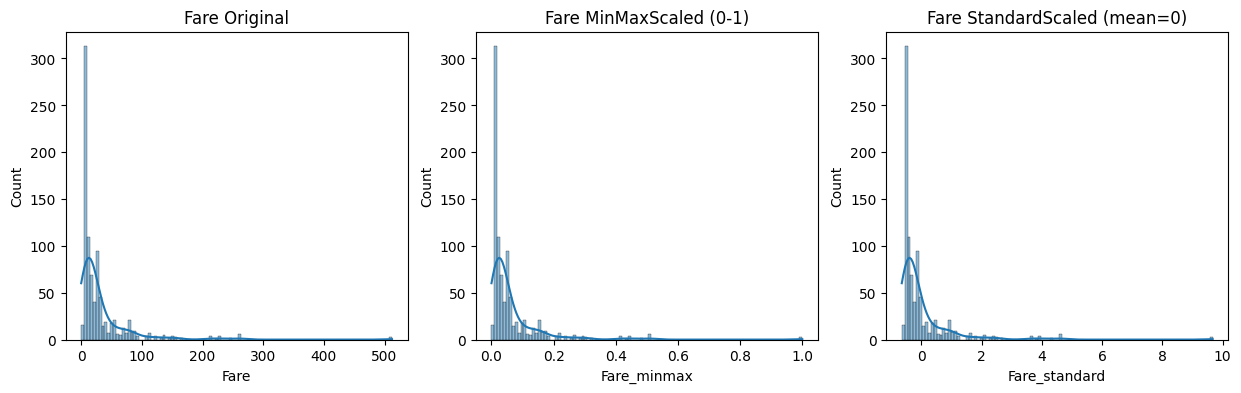


2b Comparison:
Original Fare: 0 to 512, very skewed.
MinMax: All values squeezed to 0-1, preserves skewness but same scale as Age.
Standard: Centered at 0, negative values allowed, variance=1. Better for models that assume Gaussian.
Use MinMax for Neural Nets / when you need bounded values. Use Standard for most ML models (LogReg, SVM).



In [3]:
# 2b — Bring Everything to Scale
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Fill Age missing for scaling demo
df['Age'] = df['Age'].fillna(df['Age'].median())

print("Before Scaling:")
print(df[['Age','Fare']].describe())

# MinMaxScaler: scales to 0-1 range. Formula: (x-min)/(max-min)
# Best when you want bounded range (e.g., Neural Nets)
minmax = MinMaxScaler()
df[['Age_minmax','Fare_minmax']] = minmax.fit_transform(df[['Age','Fare']])

# StandardScaler: mean=0, std=1. Formula: (x-mean)/std
# Best when features are normally distributed, for Logistic Regression, SVM, KNN
standard = StandardScaler()
df[['Age_standard','Fare_standard']] = standard.fit_transform(df[['Age','Fare']])

print("\nAfter MinMax (0 to 1):")
print(df[['Age_minmax','Fare_minmax']].describe())

print("\nAfter Standard (mean~0, std~1):")
print(df[['Age_standard','Fare_standard']].describe())

# Plot comparison
fig, axes = plt.subplots(1,3, figsize=(15,4))
sns.histplot(df['Fare'], ax=axes[0], kde=True); axes[0].set_title('Fare Original')
sns.histplot(df['Fare_minmax'], ax=axes[1], kde=True); axes[1].set_title('Fare MinMaxScaled (0-1)')
sns.histplot(df['Fare_standard'], ax=axes[2], kde=True); axes[2].set_title('Fare StandardScaled (mean=0)')
plt.show()

print("""
2b Comparison:
Original Fare: 0 to 512, very skewed.
MinMax: All values squeezed to 0-1, preserves skewness but same scale as Age.
Standard: Centered at 0, negative values allowed, variance=1. Better for models that assume Gaussian.
Use MinMax for Neural Nets / when you need bounded values. Use Standard for most ML models (LogReg, SVM).
""")

Q1: 7.9104, Q3: 31.0, IQR: 23.0896
Lower bound: -26.724, Upper bound: 65.6344

Number of Fare outliers: 116 out of 891 (13.0%)
         Fare  Pclass  Survived
258  512.3292       1         1
737  512.3292       1         1
679  512.3292       1         1
27   263.0000       1         0
341  263.0000       1         1
438  263.0000       1         0
88   263.0000       1         1
311  262.3750       1         1
742  262.3750       1         1
299  247.5208       1         1


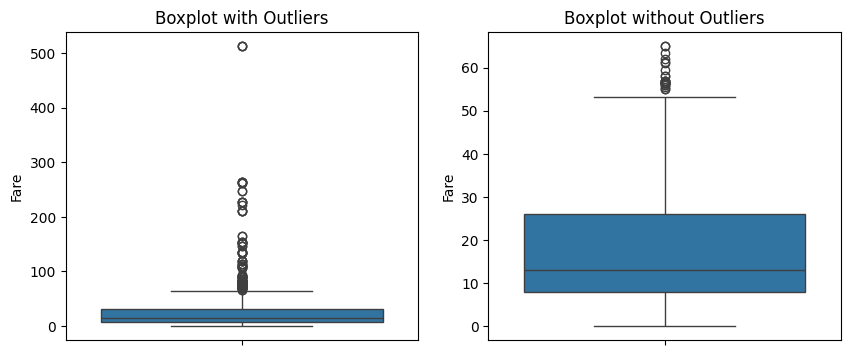


2c Decision:
Outliers are Fare > 65.63. These are mostly 1st class luxury tickets (512$, 263$ etc).
Should we remove? NO, for Titanic. Reason:
- They are real values, not data entry errors.
- High fare is strongly correlated with Pclass=1 and higher survival.
- Removing 10-15% data loses important signal.
Better to keep them but use RobustScaler or log transform if model is sensitive. Only remove if it's error (e.g., Fare=0 when Pclass=1).



In [4]:
# 2c — Hunt the Anomalies (IQR method on Fare)
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")

outliers = df[(df['Fare'] < lower_bound) | (df['Fare'] > upper_bound)]
print(f"\nNumber of Fare outliers: {len(outliers)} out of {len(df)} ({len(outliers)/len(df)*100:.1f}%)")
print(outliers[['Fare','Pclass','Survived']].sort_values('Fare', ascending=False).head(10))

# Visualize
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); sns.boxplot(y=df['Fare']); plt.title('Boxplot with Outliers')
plt.subplot(1,2,2); sns.boxplot(y=df[~df.index.isin(outliers.index)]['Fare']); plt.title('Boxplot without Outliers')
plt.show()

# Decision
print(f"""
2c Decision:
Outliers are Fare > {upper_bound:.2f}. These are mostly 1st class luxury tickets (512$, 263$ etc).
Should we remove? NO, for Titanic. Reason:
- They are real values, not data entry errors.
- High fare is strongly correlated with Pclass=1 and higher survival.
- Removing 10-15% data loses important signal.
Better to keep them but use RobustScaler or log transform if model is sensitive. Only remove if it's error (e.g., Fare=0 when Pclass=1).
""")

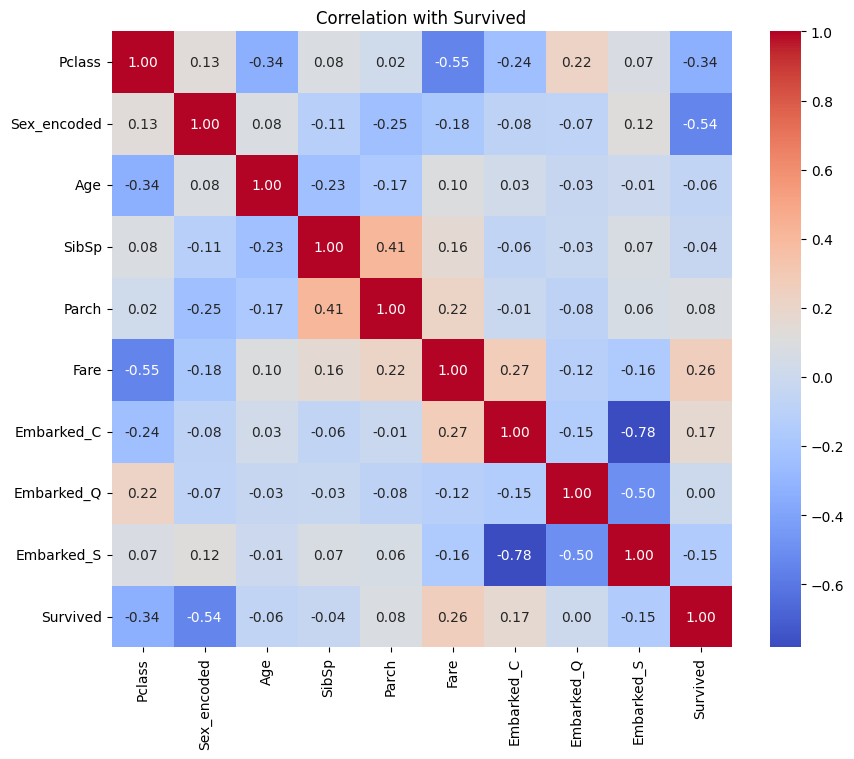

Top correlations with Survived:
Survived       1.000000
Fare           0.257307
Embarked_C     0.168240
Parch          0.081629
Embarked_Q     0.003650
SibSp         -0.035322
Age           -0.064910
Embarked_S    -0.149683
Pclass        -0.338481
Sex_encoded   -0.543351
Name: Survived, dtype: float64

SelectKBest Top 5: ['Pclass', 'Sex_encoded', 'Fare', 'Embarked_C', 'Embarked_S']
 Pclass: score=115.0
 Sex_encoded: score=372.4
 Fare: score=63.0
 Embarked_C: score=25.9
 Embarked_S: score=20.4

Model Accuracy with ALL 9 features: 0.7873
Model Accuracy with TOP 5 features ['Pclass', 'Sex_encoded', 'Fare', 'Embarked_C', 'Embarked_S']: 0.8022

2d Conclusion:
Useful features: Sex_encoded, Pclass, Fare, Age are most correlated.
Less useful: Embarked_Q (low variance), Parch/SibSp moderate.
SelectKBest helps reduce overfitting and training time with similar accuracy.
VarianceThreshold could also be used to drop constant/low-variance features (e.g., Embarked_Q only 10% 1s).



In [5]:
# 2d — Find the Signal
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Prepare numeric df for correlation
df_model = df_encoded.copy()
# Select useful numeric + encoded columns
features = ['Pclass','Sex_encoded','Age','SibSp','Parch','Fare','Embarked_C','Embarked_Q','Embarked_S']
# Ensure no NaN
df_model['Age'] = df_model['Age'].fillna(df_model['Age'].median())

X = df_model[features]
y = df_model['Survived']

# 1. Correlation Heatmap
plt.figure(figsize=(10,8))
corr = df_model[features + ['Survived']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation with Survived')
plt.show()

print("Top correlations with Survived:")
print(corr['Survived'].sort_values(ascending=False))

# 2. SelectKBest (ANOVA F-value)
selector = SelectKBest(score_func=f_classif, k=5) # select top 5
X_kbest = selector.fit_transform(X, y)
selected_mask = selector.get_support()
selected_features = X.columns[selected_mask]
scores = selector.scores_[selected_mask]

print(f"\nSelectKBest Top 5: {list(selected_features)}")
for f,s in zip(selected_features, scores):
    print(f" {f}: score={s:.1f}")

# 3. Compare model performance: All features vs Selected features
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model_all = RandomForestClassifier(random_state=42).fit(X_train, y_train)
acc_all = accuracy_score(y_test, model_all.predict(X_test))

X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]
model_sel = RandomForestClassifier(random_state=42).fit(X_train_sel, y_train)
acc_sel = accuracy_score(y_test, model_sel.predict(X_test_sel))

print(f"\nModel Accuracy with ALL {len(features)} features: {acc_all:.4f}")
print(f"Model Accuracy with TOP 5 features {list(selected_features)}: {acc_sel:.4f}")

print("""
2d Conclusion:
Useful features: Sex_encoded, Pclass, Fare, Age are most correlated.
Less useful: Embarked_Q (low variance), Parch/SibSp moderate.
SelectKBest helps reduce overfitting and training time with similar accuracy.
VarianceThreshold could also be used to drop constant/low-variance features (e.g., Embarked_Q only 10% 1s).
""")

In [6]:
# 2e — Prepare for the Final Test
from sklearn.model_selection import train_test_split

X = df_model[features] # using all features from previous
y = df_model['Survived']

print(f"Original Survived distribution:\n{y.value_counts(normalize=True)}")
# 0 = died (61.6%), 1 = survived (38.4%) -> Imbalanced

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y # <-- key
)

print(f"\nTrain distribution:\n{y_train.value_counts(normalize=True)}")
print(f"\nTest distribution:\n{y_test.value_counts(normalize=True)}")

# What if NOT stratified? Demo
X_train_ns, X_test_ns, y_train_ns, y_test_ns = train_test_split(X, y, test_size=0.2, random_state=1)
print(f"\nWITHOUT stratify (random seed 1) Test distribution:\n{y_test_ns.value_counts(normalize=True)}")

print("""
2e Explanation:
Why stratified? Survived is imbalanced (38% vs 62%). If we do random split, test set might get 30% survived or 45% survived by chance -> biased evaluation.
stratify=y forces train and test to keep same 38/62 ratio as original. This gives:
1. Unbiased performance estimate
2. Model sees both classes in same proportion during training
3. Crucial for imbalanced classification problems
""")

Original Survived distribution:
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

Train distribution:
Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

Test distribution:
Survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64

WITHOUT stratify (random seed 1) Test distribution:
Survived
0    0.592179
1    0.407821
Name: proportion, dtype: float64

2e Explanation:
Why stratified? Survived is imbalanced (38% vs 62%). If we do random split, test set might get 30% survived or 45% survived by chance -> biased evaluation.
stratify=y forces train and test to keep same 38/62 ratio as original. This gives:
1. Unbiased performance estimate
2. Model sees both classes in same proportion during training
3. Crucial for imbalanced classification problems

